# BANKRUPTCY PREVENTION

In [ ]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Excel file
df = pd.read_excel(r"C:\\Users\\Admin\\Downloads\\bankruptcy-prevention (1).xlsx")

# Split single column (because data is separated by ;)
df = df.iloc[:, 0].str.split(';', expand=True)

# Rename columns
df.columns = ['industrial_risk',
              'management_risk',
              'financial_flexibility',
              'credibility',
              'competitiveness',
              'operating_risk',
              'class']

In [4]:
# BASIC DATA CHECK

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nData Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (250, 7)

Columns: ['industrial_risk', 'management_risk', 'financial_flexibility', 'credibility', 'competitiveness', 'operating_risk', 'class']

First 5 rows:
   industrial_risk management_risk financial_flexibility credibility  \
0             0.5               1                     0           0   
1               0               1                     0           0   
2               1               0                     0           0   
3             0.5               0                     0         0.5   
4               1               1                     0           0   

  competitiveness operating_risk       class  
0               0            0.5  bankruptcy  
1               0              1  bankruptcy  
2               0              1  bankruptcy  
3               0              1  bankruptcy  
4               0              1  bankruptcy  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Col

In [5]:
# Convert first 6 columns to float
for col in df.columns[:-1]:
    df[col] = df[col].astype(float)

print("\nData Types After Conversion:\n", df.dtypes) 


Data Types After Conversion:
 industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                     object
dtype: object


In [6]:
# TARGET ENCODING

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

print("\nClass Distribution:\n", df['class'].value_counts())


Class Distribution:
 class
1    143
0    107
Name: count, dtype: int64


In [7]:
# satistical summury 
print(df.describe())

       industrial_risk  management_risk  financial_flexibility  credibility  \
count       250.000000       250.000000             250.000000   250.000000   
mean          0.518000         0.614000               0.376000     0.470000   
std           0.411526         0.410705               0.401583     0.415682   
min           0.000000         0.000000               0.000000     0.000000   
25%           0.000000         0.500000               0.000000     0.000000   
50%           0.500000         0.500000               0.500000     0.500000   
75%           1.000000         1.000000               0.500000     1.000000   
max           1.000000         1.000000               1.000000     1.000000   

       competitiveness  operating_risk       class  
count       250.000000      250.000000  250.000000  
mean          0.476000        0.570000    0.572000  
std           0.440682        0.434575    0.495781  
min           0.000000        0.000000    0.000000  
25%           0.000000 

In [8]:
# VISUALIZATION


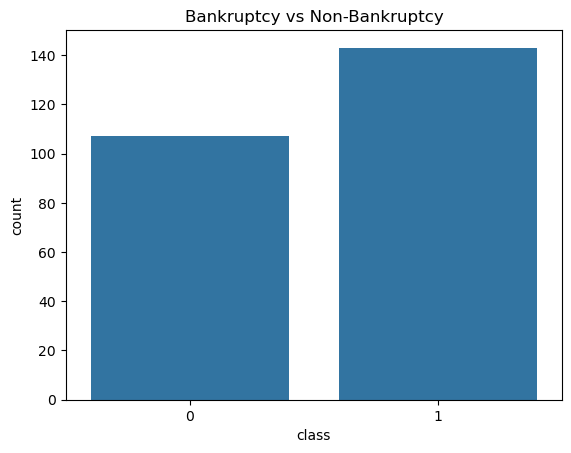

In [9]:
# Class Distribution
sns.countplot(x='class', data=df)
plt.title("Bankruptcy vs Non-Bankruptcy")
plt.show()

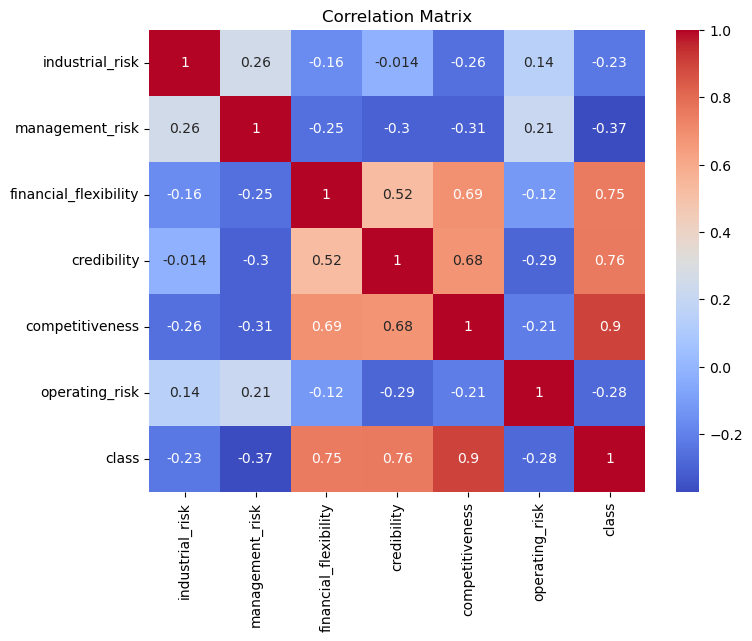

In [10]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (200, 6)
Testing Size: (50, 6)


In [12]:
# Import required libraries:

from sklearn.metrics import accuracy_score

In [13]:
# Logistic Regression 

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 1.0


In [14]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.98


In [ ]:
# Random Forest 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

In [ ]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

In [ ]:
# SVM

from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

In [ ]:
# MODEL EVALUATION


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
# Classification Report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

In [ ]:
# ROC Curve

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [29]:

import pickle

pickle.dump(rf, open("bankruptcy_model.pkl", "wb"))